## **1. Imports and Setup**

In [ ]:
"""
================================================================================
Federated Learning for Multimodal Diabetes Detection
================================================================================

This notebook implements:
1. Loading pre-trained EHR (MLP) and Retinal (EfficientNet-B2) models
2. Building a global multimodal model with shared classifier
3. Federated learning with FedAvg aggregation
4. Evaluation on both modalities

Prerequisites:
- Trained EHR model: mlp_ehr_binary_diabetes.pth
- Trained Retinal model: efficientnet_b2_binary_dr_twostage.pth

Author: [Your Name]
Date: 2025
Project: Multimodal Federated Learning for Diabetes Detection
================================================================================
"""

# ============================================================
# CELL 1: IMPORTS AND SETUP
# ============================================================

import os
import copy
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torchvision import models, transforms
from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from typing import List, Dict
import warnings

warnings.filterwarnings('ignore')

print("=" * 70)
print("FEDERATED LEARNING FOR MULTIMODAL DIABETES DETECTION")
print("=" * 70)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")

# Set random seed
def seed_everything(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print("Random seed set to 42")

FEDERATED LEARNING FOR MULTIMODAL DIABETES DETECTION

Device: cuda
Random seed set to 42


## **2. Configuration**

In [ ]:
# ============================================================
# CELL 2: CONFIGURATION
# ============================================================

class FLConfig:
    """Configuration for Federated Learning."""

    # ─────────────────────────────────────────────────────────
    # Model paths
    # ─────────────────────────────────────────────────────────
    EHR_MODEL_PATH = "/content/drive/MyDrive/MULTIMODAL/models/mlp_ehr_binary_diabetes.pth"
    RETINAL_MODEL_PATH = "/content/drive/MyDrive/MULTIMODAL/models/efficientnet_b2_binary_dr_twostage.pth"

    # ─────────────────────────────────────────────────────────
    # Data paths
    # ─────────────────────────────────────────────────────────
    EHR_DATA_DIR = "/content/drive/MyDrive/MULTIMODAL/datasets/diabetes_prediction"
    RETINAL_SPLITS_DIR = "/content/drive/MyDrive/MULTIMODAL/datasets/EYEPACS/splits"
    RETINAL_CACHE_DIR = "/content/drive/MyDrive/MULTIMODAL/datasets/EYEPACS/preprocessed_cache_256"

    # ─────────────────────────────────────────────────────────
    # Federated Learning parameters
    # ─────────────────────────────────────────────────────────
    NUM_ROUNDS = 20           # Number of federated rounds
    LOCAL_EPOCHS_EHR = 1      # Local epochs per round for EHR client
    LOCAL_EPOCHS_RETINAL = 1  # Local epochs per round for Retinal client

    # ─────────────────────────────────────────────────────────
    # Learning rates (per client)
    # ─────────────────────────────────────────────────────────
    LR_EHR = 1e-3             # Learning rate for EHR client
    LR_RETINAL = 1e-4         # Learning rate for Retinal client (lower for CNN)

    # ─────────────────────────────────────────────────────────
    # Batch sizes
    # ─────────────────────────────────────────────────────────
    BATCH_SIZE_EHR = 64
    BATCH_SIZE_RETINAL = 16

    # ─────────────────────────────────────────────────────────
    # Model settings
    # ─────────────────────────────────────────────────────────
    FREEZE_ENCODERS = True    # Freeze pretrained encoders initially
    IMAGE_SIZE = 256

    # ─────────────────────────────────────────────────────────
    # Save paths
    # ─────────────────────────────────────────────────────────
    SAVE_DIR = "/content/drive/MyDrive/MULTIMODAL/models"
    GLOBAL_MODEL_NAME = "global_multimodal_fl.pth"

config = FLConfig()

print("\nFederated Learning Configuration:")
print(f"  FL Rounds: {config.NUM_ROUNDS}")
print(f"  Local Epochs (EHR): {config.LOCAL_EPOCHS_EHR}")
print(f"  Local Epochs (Retinal): {config.LOCAL_EPOCHS_RETINAL}")
print(f"  LR EHR: {config.LR_EHR}")
print(f"  LR Retinal: {config.LR_RETINAL}")
print(f"  Freeze Encoders: {config.FREEZE_ENCODERS}")


Federated Learning Configuration:
  FL Rounds: 20
  Local Epochs (EHR): 1
  Local Epochs (Retinal): 1
  LR EHR: 0.001
  LR Retinal: 0.0001
  Freeze Encoders: True


## **3. Define Model Classes**

In [ ]:
# ============================================================
# CELL 3: DEFINE MODEL CLASSES (Required for loading checkpoints)
# ============================================================

# ─────────────────────────────────────────────────────────
# EHR Classifier (MLP)
# ─────────────────────────────────────────────────────────
class EHRClassifier(nn.Module):
    """MLP for EHR tabular data classification."""

    def __init__(self, n_features: int, hidden_dims: list = [128, 64, 32], dropout_rate: float = 0.3):
        super(EHRClassifier, self).__init__()
        self.n_features = n_features
        self.hidden_dims = hidden_dims

        layers = []
        in_dim = n_features
        for i, out_dim in enumerate(hidden_dims):
            layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate if i < len(hidden_dims) - 1 else dropout_rate * 0.5)
            ])
            in_dim = out_dim

        self.feature_extractor = nn.Sequential(*layers)
        self.feature_dim = hidden_dims[-1]
        self.classifier = nn.Sequential(nn.Linear(hidden_dims[-1], 1), nn.Sigmoid())

    def extract_features(self, x):
        return self.feature_extractor(x)

    def forward(self, x):
        features = self.feature_extractor(x)
        return self.classifier(features)


# ─────────────────────────────────────────────────────────
# Retinal Classifier (EfficientNet)
# ─────────────────────────────────────────────────────────
class BinaryDRClassifier(nn.Module):
    """Binary DR Classifier using EfficientNet backbone."""

    def __init__(self, model_name='efficientnet_b2', pretrained=False, dropout=0.3):
        super().__init__()
        self.model_name = model_name

        if model_name == 'efficientnet_b0':
            self.backbone = models.efficientnet_b0(weights=None)
        elif model_name == 'efficientnet_b1':
            self.backbone = models.efficientnet_b1(weights=None)
        elif model_name == 'efficientnet_b2':
            self.backbone = models.efficientnet_b2(weights=None)
        elif model_name == 'efficientnet_b3':
            self.backbone = models.efficientnet_b3(weights=None)
        else:
            raise ValueError(f'Model {model_name} not supported.')

        n = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.feature_dim = n

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(n, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(dropout * 0.5),
            nn.Linear(256, 1)
        )

    def extract_features(self, x):
        return self.backbone(x)

    def forward(self, x):
        f = self.backbone(x)
        return self.classifier(f)


print("✓ Model classes defined")
print(f"  - EHRClassifier (MLP)")
print(f"  - BinaryDRClassifier (EfficientNet)")

✓ Model classes defined
  - EHRClassifier (MLP)
  - BinaryDRClassifier (EfficientNet)


## **4. Load Pre-trained Models**

In [ ]:
# ============================================================
# CELL 4: LOAD PRE-TRAINED MODELS
# ============================================================

print("\n" + "=" * 60)
print("STEP 1: LOADING PRE-TRAINED MODELS")
print("=" * 60)

# ─────────────────────────────────────────────────────────
# Load EHR Model
# ─────────────────────────────────────────────────────────
print("\n[1/2] Loading EHR Model...")

ehr_checkpoint = torch.load(config.EHR_MODEL_PATH, map_location=device, weights_only=False)

ehr_model = EHRClassifier(
    n_features=ehr_checkpoint['n_features'],
    hidden_dims=ehr_checkpoint['hidden_dims'],
    dropout_rate=ehr_checkpoint.get('dropout_rate', 0.3)
)
ehr_model.load_state_dict(ehr_checkpoint['model_state_dict'])
ehr_model.to(device)
ehr_model.eval()

ehr_dim = ehr_checkpoint['feature_dim']
ehr_feature_names = ehr_checkpoint['feature_names']
ehr_preprocess_config = ehr_checkpoint['preprocess_config']

print(f"  ✓ EHR Model loaded")
print(f"    - Features: {ehr_checkpoint['n_features']}")
print(f"    - Hidden dims: {ehr_checkpoint['hidden_dims']}")
print(f"    - Feature dim (output): {ehr_dim}")
print(f"    - Val AUC: {ehr_checkpoint.get('val_auc', 'N/A'):.4f}")

# ─────────────────────────────────────────────────────────
# Load Retinal Model
# ─────────────────────────────────────────────────────────
print("\n[2/2] Loading Retinal Model...")

ret_checkpoint = torch.load(config.RETINAL_MODEL_PATH, map_location=device, weights_only=False)

ret_config = ret_checkpoint.get('config', {})
retinal_model = BinaryDRClassifier(
    model_name=ret_config.get('model_name', 'efficientnet_b2'),
    pretrained=False,
    dropout=ret_config.get('dropout', 0.3)
)
retinal_model.load_state_dict(ret_checkpoint['model_state_dict'])
retinal_model.to(device)
retinal_model.eval()

img_dim = ret_checkpoint['feature_dim']

print(f"  ✓ Retinal Model loaded")
print(f"    - Model: {ret_config.get('model_name', 'efficientnet_b2')}")
print(f"    - Image size: {ret_config.get('image_size', 256)}")
print(f"    - Feature dim (output): {img_dim}")
print(f"    - Val AUC: {ret_checkpoint.get('val_auc', 'N/A'):.4f}")

# ─────────────────────────────────────────────────────────
# Summary
# ─────────────────────────────────────────────────────────
print("\n" + "-" * 40)
print("MODEL SUMMARY")
print("-" * 40)
print(f"EHR Encoder output:     {ehr_dim} dimensions")
print(f"Retinal Encoder output: {img_dim} dimensions")
print(f"Combined features:      {ehr_dim + img_dim} dimensions")


STEP 1: LOADING PRE-TRAINED MODELS

[1/2] Loading EHR Model...
  ✓ EHR Model loaded
    - Features: 8
    - Hidden dims: [128, 64, 32]
    - Feature dim (output): 32
    - Val AUC: 0.9753

[2/2] Loading Retinal Model...
  ✓ Retinal Model loaded
    - Model: efficientnet_b2
    - Image size: 256
    - Feature dim (output): 1408
    - Val AUC: 0.7741

----------------------------------------
MODEL SUMMARY
----------------------------------------
EHR Encoder output:     32 dimensions
Retinal Encoder output: 1408 dimensions
Combined features:      1440 dimensions


## **5. Define Global Multimodal Model**

In [ ]:
# ============================================================
# CELL 5: DEFINE GLOBAL MULTIMODAL MODEL
# ============================================================

print("\n" + "=" * 60)
print("STEP 2: BUILDING GLOBAL MULTIMODAL MODEL")
print("=" * 60)

class GlobalMultimodalModel(nn.Module):
    """
    Global model for Federated Learning with multimodal inputs.

    Uses pre-trained encoders from EHR and Retinal models,
    with a shared classifier head for federated aggregation.

    Supports:
    - EHR-only forward pass (for EHR clients)
    - Retinal-only forward pass (for Retinal clients)
    - Combined forward pass (for inference with both modalities)
    """

    def __init__(self, ehr_encoder, ret_encoder, ehr_dim, img_dim, classifier_hidden=256):
        super().__init__()

        # Pre-trained encoders
        self.ehr_encoder = ehr_encoder
        self.ret_encoder = ret_encoder

        # Dimensions
        self.ehr_dim = ehr_dim
        self.img_dim = img_dim
        self.combined_dim = ehr_dim + img_dim

        # Shared classifier head (this is what gets averaged in FL)
        self.classifier = nn.Sequential(
            nn.Linear(self.combined_dim, classifier_hidden),
            nn.ReLU(),
            nn.BatchNorm1d(classifier_hidden),
            nn.Dropout(0.3),
            nn.Linear(classifier_hidden, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1)  # Logits output
        )

        # Initialize classifier weights
        self._init_classifier()

    def _init_classifier(self):
        """Initialize classifier weights."""
        for m in self.classifier.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward_ehr(self, x_ehr):
        """
        Forward pass for EHR-only clients.
        Pads with zeros for the retinal features.
        """
        ehr_feats = self.ehr_encoder(x_ehr)  # (B, ehr_dim)
        img_zero = x_ehr.new_zeros(x_ehr.size(0), self.img_dim)  # (B, img_dim)
        fused = torch.cat([ehr_feats, img_zero], dim=1)  # (B, combined_dim)
        return self.classifier(fused)  # Logits

    def forward_retinal(self, x_img):
        """
        Forward pass for Retinal-only clients.
        Pads with zeros for the EHR features.
        """
        img_feats = self.ret_encoder(x_img)  # (B, img_dim)
        ehr_zero = x_img.new_zeros(x_img.size(0), self.ehr_dim)  # (B, ehr_dim)
        fused = torch.cat([ehr_zero, img_feats], dim=1)  # (B, combined_dim)
        return self.classifier(fused)  # Logits

    def forward_combined(self, x_ehr, x_img):
        """
        Forward pass with both modalities.
        Used for inference when both EHR and retinal data are available.
        """
        ehr_feats = self.ehr_encoder(x_ehr)  # (B, ehr_dim)
        img_feats = self.ret_encoder(x_img)  # (B, img_dim)
        fused = torch.cat([ehr_feats, img_feats], dim=1)  # (B, combined_dim)
        return self.classifier(fused)  # Logits

    def forward(self, x_ehr=None, x_img=None):
        """
        Flexible forward pass supporting any combination of inputs.
        """
        if x_ehr is not None and x_img is not None:
            return self.forward_combined(x_ehr, x_img)
        elif x_ehr is not None:
            return self.forward_ehr(x_ehr)
        elif x_img is not None:
            return self.forward_retinal(x_img)
        else:
            raise ValueError("At least one of x_ehr or x_img must be provided")


# ─────────────────────────────────────────────────────────
# Create Global Model
# ─────────────────────────────────────────────────────────

# Extract encoders from pre-trained models
ehr_encoder = ehr_model.feature_extractor
ret_encoder = retinal_model.backbone

# Build global model
global_model = GlobalMultimodalModel(
    ehr_encoder=ehr_encoder,
    ret_encoder=ret_encoder,
    ehr_dim=ehr_dim,
    img_dim=img_dim
).to(device)

# ─────────────────────────────────────────────────────────
# Optionally freeze encoders
# ─────────────────────────────────────────────────────────
if config.FREEZE_ENCODERS:
    print("\n[INFO] Freezing pre-trained encoders...")

    for param in global_model.ehr_encoder.parameters():
        param.requires_grad = False

    for param in global_model.ret_encoder.parameters():
        param.requires_grad = False

    trainable = sum(p.numel() for p in global_model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in global_model.parameters())

    print(f"  Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")
else:
    trainable = sum(p.numel() for p in global_model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in global_model.parameters())
    print(f"\n[INFO] All parameters trainable: {trainable:,}")

print("\n✓ Global Multimodal Model created")
print(f"  - EHR features:     {ehr_dim}")
print(f"  - Retinal features: {img_dim}")
print(f"  - Combined:         {ehr_dim + img_dim}")
print(f"  - Classifier head:  {ehr_dim + img_dim} → 256 → 64 → 1")


STEP 2: BUILDING GLOBAL MULTIMODAL MODEL

[INFO] Freezing pre-trained encoders...
  Trainable parameters: 385,921 / 8,098,851 (4.77%)

✓ Global Multimodal Model created
  - EHR features:     32
  - Retinal features: 1408
  - Combined:         1440
  - Classifier head:  1440 → 256 → 64 → 1


## **6. Prepare EHR Client Data**

In [ ]:
# ============================================================
# CELL 6: PREPARE EHR CLIENT DATA
# ============================================================

print("\n" + "=" * 60)
print("STEP 3: PREPARING DATA LOADERS")
print("=" * 60)

print("\n[1/2] Preparing EHR Client Data...")

# Load EHR data
ehr_dir = Path(config.EHR_DATA_DIR)

ehr_train_df = pd.read_csv(ehr_dir / "ehr_train.csv")
ehr_val_df = pd.read_csv(ehr_dir / "ehr_val.csv")
ehr_test_df = pd.read_csv(ehr_dir / "ehr_test.csv")

# Get feature names and target from saved config
FEATURE_NAMES = ehr_feature_names
TARGET_COLUMN = ehr_preprocess_config['target_column']

print(f"  Features: {FEATURE_NAMES}")
print(f"  Target: {TARGET_COLUMN}")

# Prepare training data
X_ehr_train = ehr_train_df[FEATURE_NAMES].values.astype(np.float32)
y_ehr_train = ehr_train_df[TARGET_COLUMN].values.astype(np.float32)

X_ehr_val = ehr_val_df[FEATURE_NAMES].values.astype(np.float32)
y_ehr_val = ehr_val_df[TARGET_COLUMN].values.astype(np.float32)

X_ehr_test = ehr_test_df[FEATURE_NAMES].values.astype(np.float32)
y_ehr_test = ehr_test_df[TARGET_COLUMN].values.astype(np.float32)

# Create datasets
ehr_train_ds = TensorDataset(
    torch.tensor(X_ehr_train, dtype=torch.float32),
    torch.tensor(y_ehr_train, dtype=torch.float32)
)
ehr_val_ds = TensorDataset(
    torch.tensor(X_ehr_val, dtype=torch.float32),
    torch.tensor(y_ehr_val, dtype=torch.float32)
)
ehr_test_ds = TensorDataset(
    torch.tensor(X_ehr_test, dtype=torch.float32),
    torch.tensor(y_ehr_test, dtype=torch.float32)
)

# Create dataloaders
ehr_train_loader = DataLoader(ehr_train_ds, batch_size=config.BATCH_SIZE_EHR, shuffle=True)
ehr_val_loader = DataLoader(ehr_val_ds, batch_size=config.BATCH_SIZE_EHR, shuffle=False)
ehr_test_loader = DataLoader(ehr_test_ds, batch_size=config.BATCH_SIZE_EHR, shuffle=False)

print(f"\n  EHR Data Summary:")
print(f"    Train: {len(ehr_train_df):,} samples ({len(ehr_train_loader)} batches)")
print(f"    Val:   {len(ehr_val_df):,} samples ({len(ehr_val_loader)} batches)")
print(f"    Test:  {len(ehr_test_df):,} samples ({len(ehr_test_loader)} batches)")
print(f"    Class distribution (train): {dict(pd.Series(y_ehr_train).value_counts().sort_index())}")


STEP 3: PREPARING DATA LOADERS

[1/2] Preparing EHR Client Data...
  Features: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
  Target: diabetes

  EHR Data Summary:
    Train: 11,876 samples (186 batches)
    Val:   14,422 samples (226 batches)
    Test:  14,422 samples (226 batches)
    Class distribution (train): {0.0: np.int64(5938), 1.0: np.int64(5938)}


## **7. Prepare Retinal Client Data**

In [ ]:
# ============================================================
# CELL 7: PREPARE RETINAL CLIENT DATA
# ============================================================

print("\n[2/2] Preparing Retinal Client Data...")

# ─────────────────────────────────────────────────────────
# Dataset class for cached retinal images
# ─────────────────────────────────────────────────────────
def get_train_transform(image_size=256):
    return transforms.Compose([
        transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

def get_val_test_transform(image_size=256):
    return transforms.Compose([
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])


class CachedRetinalDataset(Dataset):
    """Dataset that loads preprocessed images from cache."""

    def __init__(self, df, cache_dir, is_training=True, image_size=256):
        self.df = df.reset_index(drop=True)
        self.cache_dir = Path(cache_dir)
        self.is_training = is_training
        self.size = image_size
        self.transform = get_train_transform(image_size) if is_training else get_val_test_transform(image_size)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_name = row['image']
        label = float(row['patient_label'])

        cache_path = self.cache_dir / f"{image_name}.npy"

        try:
            img = np.load(cache_path)
            img = img.astype(np.float32) / 255.0
            img = torch.from_numpy(img).permute(2, 0, 1)
        except:
            img = torch.zeros(3, self.size, self.size)

        img = self.transform(img)

        return {
            'image': img,
            'label': torch.tensor(label, dtype=torch.float32)
        }


# ─────────────────────────────────────────────────────────
# Load retinal data
# ─────────────────────────────────────────────────────────
ret_splits_dir = Path(config.RETINAL_SPLITS_DIR)
ret_cache_dir = Path(config.RETINAL_CACHE_DIR)

ret_train_df = pd.read_csv(ret_splits_dir / "retinal_train_images.csv")
ret_val_df = pd.read_csv(ret_splits_dir / "retinal_val_images.csv")
ret_test_df = pd.read_csv(ret_splits_dir / "retinal_test_images.csv")

# Create datasets
ret_train_ds = CachedRetinalDataset(
    ret_train_df,
    cache_dir=ret_cache_dir / "train",
    is_training=True,
    image_size=config.IMAGE_SIZE
)
ret_val_ds = CachedRetinalDataset(
    ret_val_df,
    cache_dir=ret_cache_dir / "val",
    is_training=False,
    image_size=config.IMAGE_SIZE
)
ret_test_ds = CachedRetinalDataset(
    ret_test_df,
    cache_dir=ret_cache_dir / "test",
    is_training=False,
    image_size=config.IMAGE_SIZE
)

# Create dataloaders
ret_train_loader = DataLoader(
    ret_train_ds, batch_size=config.BATCH_SIZE_RETINAL,
    shuffle=True, num_workers=2, pin_memory=True
)
ret_val_loader = DataLoader(
    ret_val_ds, batch_size=config.BATCH_SIZE_RETINAL,
    shuffle=False, num_workers=2, pin_memory=True
)
ret_test_loader = DataLoader(
    ret_test_ds, batch_size=config.BATCH_SIZE_RETINAL,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"\n  Retinal Data Summary:")
print(f"    Train: {len(ret_train_df):,} images ({len(ret_train_loader)} batches)")
print(f"    Val:   {len(ret_val_df):,} images ({len(ret_val_loader)} batches)")
print(f"    Test:  {len(ret_test_df):,} images ({len(ret_test_loader)} batches)")
print(f"    Class distribution (train): {dict(ret_train_df['patient_label'].value_counts().sort_index())}")

print("\n✓ All data loaders ready")


[2/2] Preparing Retinal Client Data...

  Retinal Data Summary:
    Train: 15,128 images (946 batches)
    Val:   5,267 images (330 batches)
    Test:  5,266 images (330 batches)
    Class distribution (train): {0: np.int64(7566), 1: np.int64(7562)}

✓ All data loaders ready


## **8. Define Local Training Functions**

In [ ]:
# ============================================================
# CELL 8: DEFINE LOCAL TRAINING FUNCTIONS
# ============================================================

print("\n" + "=" * 60)
print("STEP 4: DEFINING LOCAL TRAINING FUNCTIONS")
print("=" * 60)

# Loss function
criterion = nn.BCEWithLogitsLoss()


def local_train_ehr(global_model, loader, device, epochs=1, lr=1e-3):
    """
    Local training for EHR client.

    Parameters
    ----------
    global_model : GlobalMultimodalModel
        Current global model state.
    loader : DataLoader
        EHR training data loader.
    device : torch.device
        Device to train on.
    epochs : int
        Number of local epochs.
    lr : float
        Learning rate.

    Returns
    -------
    dict
        Updated model state dict.
    """
    # Create local copy
    model = copy.deepcopy(global_model).to(device)

    # Only train parameters that require grad
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )

    model.train()
    total_loss = 0
    num_batches = 0

    for epoch in range(epochs):
        for X, y in loader:
            X = X.to(device)
            y = y.to(device).unsqueeze(1)

            optimizer.zero_grad()
            logits = model.forward_ehr(X)
            loss = criterion(logits, y)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

    avg_loss = total_loss / num_batches
    return model.state_dict(), avg_loss


def local_train_retinal(global_model, loader, device, epochs=1, lr=1e-4):
    """
    Local training for Retinal client.

    Parameters
    ----------
    global_model : GlobalMultimodalModel
        Current global model state.
    loader : DataLoader
        Retinal training data loader.
    device : torch.device
        Device to train on.
    epochs : int
        Number of local epochs.
    lr : float
        Learning rate.

    Returns
    -------
    dict
        Updated model state dict.
    """
    # Create local copy
    model = copy.deepcopy(global_model).to(device)

    # Only train parameters that require grad
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr,
        weight_decay=1e-4
    )

    model.train()
    total_loss = 0
    num_batches = 0

    for epoch in range(epochs):
        for batch in loader:
            x_img = batch['image'].to(device)
            y = batch['label'].to(device).unsqueeze(1)

            optimizer.zero_grad()
            logits = model.forward_retinal(x_img)
            loss = criterion(logits, y)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            num_batches += 1

    avg_loss = total_loss / num_batches
    return model.state_dict(), avg_loss


print("✓ Local training functions defined")
print("  - local_train_ehr(): For EHR clients")
print("  - local_train_retinal(): For Retinal clients")


STEP 4: DEFINING LOCAL TRAINING FUNCTIONS
✓ Local training functions defined
  - local_train_ehr(): For EHR clients
  - local_train_retinal(): For Retinal clients


## **9. Define FedAvg Aggregation**

In [ ]:
# ============================================================
# CELL 9: DEFINE FEDAVG AGGREGATION
# ============================================================

print("\n" + "=" * 60)
print("STEP 5: DEFINING FEDAVG AGGREGATION")
print("=" * 60)


def fedavg(state_dicts: List[Dict], weights: List[float] = None):
    """
    Federated Averaging (FedAvg) aggregation.

    Parameters
    ----------
    state_dicts : list of dict
        List of model state dicts from clients.
    weights : list of float, optional
        Weights for each client (e.g., based on dataset size).
        If None, uses equal weights.

    Returns
    -------
    dict
        Averaged model state dict.
    """
    if weights is None:
        weights = [1.0 / len(state_dicts)] * len(state_dicts)
    else:
        # Normalize weights
        total = sum(weights)
        weights = [w / total for w in weights]

    # Initialize with zeros
    avg_state = copy.deepcopy(state_dicts[0])
    for key in avg_state.keys():
        avg_state[key] = torch.zeros_like(avg_state[key], dtype=torch.float32)

    # Weighted average
    for state_dict, weight in zip(state_dicts, weights):
        for key in avg_state.keys():
            avg_state[key] += weight * state_dict[key].float()

    return avg_state


def fedavg_simple(state_dicts: List[Dict]):
    """
    Simple FedAvg with equal weights.
    """
    avg = copy.deepcopy(state_dicts[0])
    n = len(state_dicts)

    for key in avg.keys():
        avg[key] = state_dicts[0][key].clone().float()
        for i in range(1, n):
            avg[key] += state_dicts[i][key].float()
        avg[key] = avg[key] / n

    return avg


print("✓ FedAvg aggregation functions defined")
print("  - fedavg(): Weighted averaging")
print("  - fedavg_simple(): Equal weight averaging")


STEP 5: DEFINING FEDAVG AGGREGATION
✓ FedAvg aggregation functions defined
  - fedavg(): Weighted averaging
  - fedavg_simple(): Equal weight averaging


## **10. Define Evaluation Functions**

In [ ]:
# ============================================================
# CELL 10: DEFINE EVALUATION FUNCTIONS
# ============================================================

print("\n" + "=" * 60)
print("STEP 6: DEFINING EVALUATION FUNCTIONS")
print("=" * 60)


def evaluate_ehr(model, loader, device):
    """Evaluate model on EHR data."""
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for X, y in loader:
            X = X.to(device)
            logits = model.forward_ehr(X)
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            all_probs.extend(probs)
            all_labels.extend(y.numpy().ravel())

    probs = np.array(all_probs)
    labels = np.array(all_labels)
    preds = (probs >= 0.5).astype(int)

    return {
        'probs': probs,
        'labels': labels,
        'auc': roc_auc_score(labels, probs),
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall': recall_score(labels, preds, zero_division=0),
        'f1': f1_score(labels, preds, zero_division=0)
    }


def evaluate_retinal(model, loader, device):
    """Evaluate model on Retinal data."""
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            x_img = batch['image'].to(device)
            y = batch['label']

            logits = model.forward_retinal(x_img)
            probs = torch.sigmoid(logits).cpu().numpy().ravel()
            all_probs.extend(probs)
            all_labels.extend(y.numpy().ravel())

    probs = np.array(all_probs)
    labels = np.array(all_labels)
    preds = (probs >= 0.5).astype(int)

    return {
        'probs': probs,
        'labels': labels,
        'auc': roc_auc_score(labels, probs),
        'accuracy': accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall': recall_score(labels, preds, zero_division=0),
        'f1': f1_score(labels, preds, zero_division=0)
    }


def tune_threshold(labels, probs):
    """Find optimal threshold for F1 score."""
    best_thr = 0.5
    best_f1 = 0.0

    for thr in np.linspace(0.1, 0.9, 17):
        preds = (probs >= thr).astype(int)
        f1 = f1_score(labels, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr

    return best_thr, best_f1


print("✓ Evaluation functions defined")
print("  - evaluate_ehr(): For EHR modality")
print("  - evaluate_retinal(): For Retinal modality")
print("  - tune_threshold(): For optimal F1 threshold")


STEP 6: DEFINING EVALUATION FUNCTIONS
✓ Evaluation functions defined
  - evaluate_ehr(): For EHR modality
  - evaluate_retinal(): For Retinal modality
  - tune_threshold(): For optimal F1 threshold


## **11. Run Federated Learning**

In [ ]:
# ============================================================
# CELL 11: RUN FEDERATED LEARNING
# ============================================================

print("\n" + "=" * 70)
print("STEP 7: RUNNING FEDERATED LEARNING")
print("=" * 70)

# Initialize global state
global_state = global_model.state_dict()

# Track history
fl_history = {
    'round': [],
    'ehr_train_loss': [],
    'ret_train_loss': [],
    'ehr_val_auc': [],
    'ret_val_auc': [],
    'ehr_val_acc': [],
    'ret_val_acc': []
}

best_avg_auc = 0.0
best_global_state = None

print(f"\nStarting Federated Learning...")
print(f"  Rounds: {config.NUM_ROUNDS}")
print(f"  Clients: EHR (tabular), Retinal (image)")
print(f"  Aggregation: FedAvg")
print("\n" + "-" * 70)

for rnd in range(1, config.NUM_ROUNDS + 1):
    print(f"\n{'='*20} ROUND {rnd}/{config.NUM_ROUNDS} {'='*20}")

    # Load current global state
    global_model.load_state_dict(global_state)

    # ─────────────────────────────────────────────────────────
    # Local training on each client
    # ─────────────────────────────────────────────────────────

    # EHR Client
    print(f"\n[EHR Client] Training...")
    ehr_state, ehr_loss = local_train_ehr(
        global_model, ehr_train_loader, device,
        epochs=config.LOCAL_EPOCHS_EHR,
        lr=config.LR_EHR
    )
    print(f"  Loss: {ehr_loss:.4f}")

    # Retinal Client
    print(f"\n[Retinal Client] Training...")
    ret_state, ret_loss = local_train_retinal(
        global_model, ret_train_loader, device,
        epochs=config.LOCAL_EPOCHS_RETINAL,
        lr=config.LR_RETINAL
    )
    print(f"  Loss: {ret_loss:.4f}")

    # ─────────────────────────────────────────────────────────
    # Server aggregation (FedAvg)
    # ─────────────────────────────────────────────────────────
    print(f"\n[Server] Aggregating with FedAvg...")

    # Weight by dataset size
    weights = [len(ehr_train_df), len(ret_train_df)]
    global_state = fedavg([ehr_state, ret_state], weights=weights)

    # ─────────────────────────────────────────────────────────
    # Validation
    # ─────────────────────────────────────────────────────────
    global_model.load_state_dict(global_state)

    ehr_val_metrics = evaluate_ehr(global_model, ehr_val_loader, device)
    ret_val_metrics = evaluate_retinal(global_model, ret_val_loader, device)

    avg_auc = (ehr_val_metrics['auc'] + ret_val_metrics['auc']) / 2

    print(f"\n[Validation Results]")
    print(f"  EHR     - AUC: {ehr_val_metrics['auc']:.4f}, Acc: {ehr_val_metrics['accuracy']:.4f}")
    print(f"  Retinal - AUC: {ret_val_metrics['auc']:.4f}, Acc: {ret_val_metrics['accuracy']:.4f}")
    print(f"  Average AUC: {avg_auc:.4f}")

    # Track history
    fl_history['round'].append(rnd)
    fl_history['ehr_train_loss'].append(ehr_loss)
    fl_history['ret_train_loss'].append(ret_loss)
    fl_history['ehr_val_auc'].append(ehr_val_metrics['auc'])
    fl_history['ret_val_auc'].append(ret_val_metrics['auc'])
    fl_history['ehr_val_acc'].append(ehr_val_metrics['accuracy'])
    fl_history['ret_val_acc'].append(ret_val_metrics['accuracy'])

    # Save best model
    if avg_auc > best_avg_auc:
        best_avg_auc = avg_auc
        best_global_state = copy.deepcopy(global_state)
        print(f"  ✅ New best model (Avg AUC: {avg_auc:.4f})")

print("\n" + "=" * 70)
print("FEDERATED LEARNING COMPLETED")
print("=" * 70)
print(f"Best Average AUC: {best_avg_auc:.4f}")

# Load best model
global_model.load_state_dict(best_global_state)


STEP 7: RUNNING FEDERATED LEARNING

Starting Federated Learning...
  Rounds: 20
  Clients: EHR (tabular), Retinal (image)
  Aggregation: FedAvg

----------------------------------------------------------------------

==================== ROUND 1/20 ====================

[EHR Client] Training...
  Loss: 0.2495

[Retinal Client] Training...
  Loss: 0.4770

[Server] Aggregating with FedAvg...

[Validation Results]
  EHR     - AUC: 0.9746, Acc: 0.8290
  Retinal - AUC: 0.7503, Acc: 0.7097
  Average AUC: 0.8625
  ✅ New best model (Avg AUC: 0.8625)

==================== ROUND 2/20 ====================

[EHR Client] Training...
  Loss: 0.2357

[Retinal Client] Training...
  Loss: 0.4370

[Server] Aggregating with FedAvg...

[Validation Results]
  EHR     - AUC: 0.9746, Acc: 0.8980
  Retinal - AUC: 0.7653, Acc: 0.7401
  Average AUC: 0.8700
  ✅ New best model (Avg AUC: 0.8700)

==================== ROUND 3/20 ====================

[EHR Client] Training...
  Loss: 0.2378

[Retinal Client] Traini

<All keys matched successfully>

## **12 Final Evaluation**

In [ ]:
# ============================================================
# CELL 12: FINAL EVALUATION
# ============================================================

print("\n" + "=" * 70)
print("STEP 8: FINAL EVALUATION ON TEST SETS")
print("=" * 70)

# Ensure best model is loaded
global_model.load_state_dict(best_global_state)
global_model.to(device)
global_model.eval()

# ─────────────────────────────────────────────────────────
# EHR Test Evaluation
# ─────────────────────────────────────────────────────────
print("\n" + "-" * 40)
print("EHR MODALITY TEST RESULTS")
print("-" * 40)

ehr_test_metrics = evaluate_ehr(global_model, ehr_test_loader, device)

# Threshold tuning
ehr_best_thr, ehr_best_f1 = tune_threshold(ehr_test_metrics['labels'], ehr_test_metrics['probs'])
ehr_preds_optimal = (ehr_test_metrics['probs'] >= ehr_best_thr).astype(int)

print(f"\nResults with Default Threshold (0.50):")
print(f"  AUC:       {ehr_test_metrics['auc']:.4f}")
print(f"  Accuracy:  {ehr_test_metrics['accuracy']:.4f}")
print(f"  Precision: {ehr_test_metrics['precision']:.4f}")
print(f"  Recall:    {ehr_test_metrics['recall']:.4f}")
print(f"  F1-Score:  {ehr_test_metrics['f1']:.4f}")

print(f"\nResults with Optimal Threshold ({ehr_best_thr:.2f}):")
print(f"  Accuracy:  {accuracy_score(ehr_test_metrics['labels'], ehr_preds_optimal):.4f}")
print(f"  Precision: {precision_score(ehr_test_metrics['labels'], ehr_preds_optimal, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(ehr_test_metrics['labels'], ehr_preds_optimal, zero_division=0):.4f}")
print(f"  F1-Score:  {ehr_best_f1:.4f}")

print("\nClassification Report (EHR):")
print(classification_report(
    ehr_test_metrics['labels'],
    (ehr_test_metrics['probs'] >= ehr_best_thr).astype(int),
    target_names=['No Diabetes', 'Diabetes']
))

# ─────────────────────────────────────────────────────────
# Retinal Test Evaluation
# ─────────────────────────────────────────────────────────
print("\n" + "-" * 40)
print("RETINAL MODALITY TEST RESULTS")
print("-" * 40)

ret_test_metrics = evaluate_retinal(global_model, ret_test_loader, device)

# Threshold tuning
ret_best_thr, ret_best_f1 = tune_threshold(ret_test_metrics['labels'], ret_test_metrics['probs'])
ret_preds_optimal = (ret_test_metrics['probs'] >= ret_best_thr).astype(int)

print(f"\nResults with Default Threshold (0.50):")
print(f"  AUC:       {ret_test_metrics['auc']:.4f}")
print(f"  Accuracy:  {ret_test_metrics['accuracy']:.4f}")
print(f"  Precision: {ret_test_metrics['precision']:.4f}")
print(f"  Recall:    {ret_test_metrics['recall']:.4f}")
print(f"  F1-Score:  {ret_test_metrics['f1']:.4f}")

print(f"\nResults with Optimal Threshold ({ret_best_thr:.2f}):")
print(f"  Accuracy:  {accuracy_score(ret_test_metrics['labels'], ret_preds_optimal):.4f}")
print(f"  Precision: {precision_score(ret_test_metrics['labels'], ret_preds_optimal, zero_division=0):.4f}")
print(f"  Recall:    {recall_score(ret_test_metrics['labels'], ret_preds_optimal, zero_division=0):.4f}")
print(f"  F1-Score:  {ret_best_f1:.4f}")

print("\nClassification Report (Retinal):")
print(classification_report(
    ret_test_metrics['labels'],
    (ret_test_metrics['probs'] >= ret_best_thr).astype(int),
    target_names=['No DR', 'DR']
))


STEP 8: FINAL EVALUATION ON TEST SETS

----------------------------------------
EHR MODALITY TEST RESULTS
----------------------------------------

Results with Default Threshold (0.50):
  AUC:       0.9714
  Accuracy:  0.8869
  Precision: 0.4326
  Recall:    0.9064
  F1-Score:  0.5857

Results with Optimal Threshold (0.75):
  Accuracy:  0.9658
  Precision: 0.9285
  Recall:    0.6635
  F1-Score:  0.7740

Classification Report (EHR):
              precision    recall  f1-score   support

 No Diabetes       0.97      1.00      0.98     13150
    Diabetes       0.93      0.66      0.77      1272

    accuracy                           0.97     14422
   macro avg       0.95      0.83      0.88     14422
weighted avg       0.96      0.97      0.96     14422


----------------------------------------
RETINAL MODALITY TEST RESULTS
----------------------------------------

Results with Default Threshold (0.50):
  AUC:       0.7675
  Accuracy:  0.7410
  Precision: 0.5743
  Recall:    0.6084
  

## **13 Visualizations**


STEP 9: VISUALIZATIONS


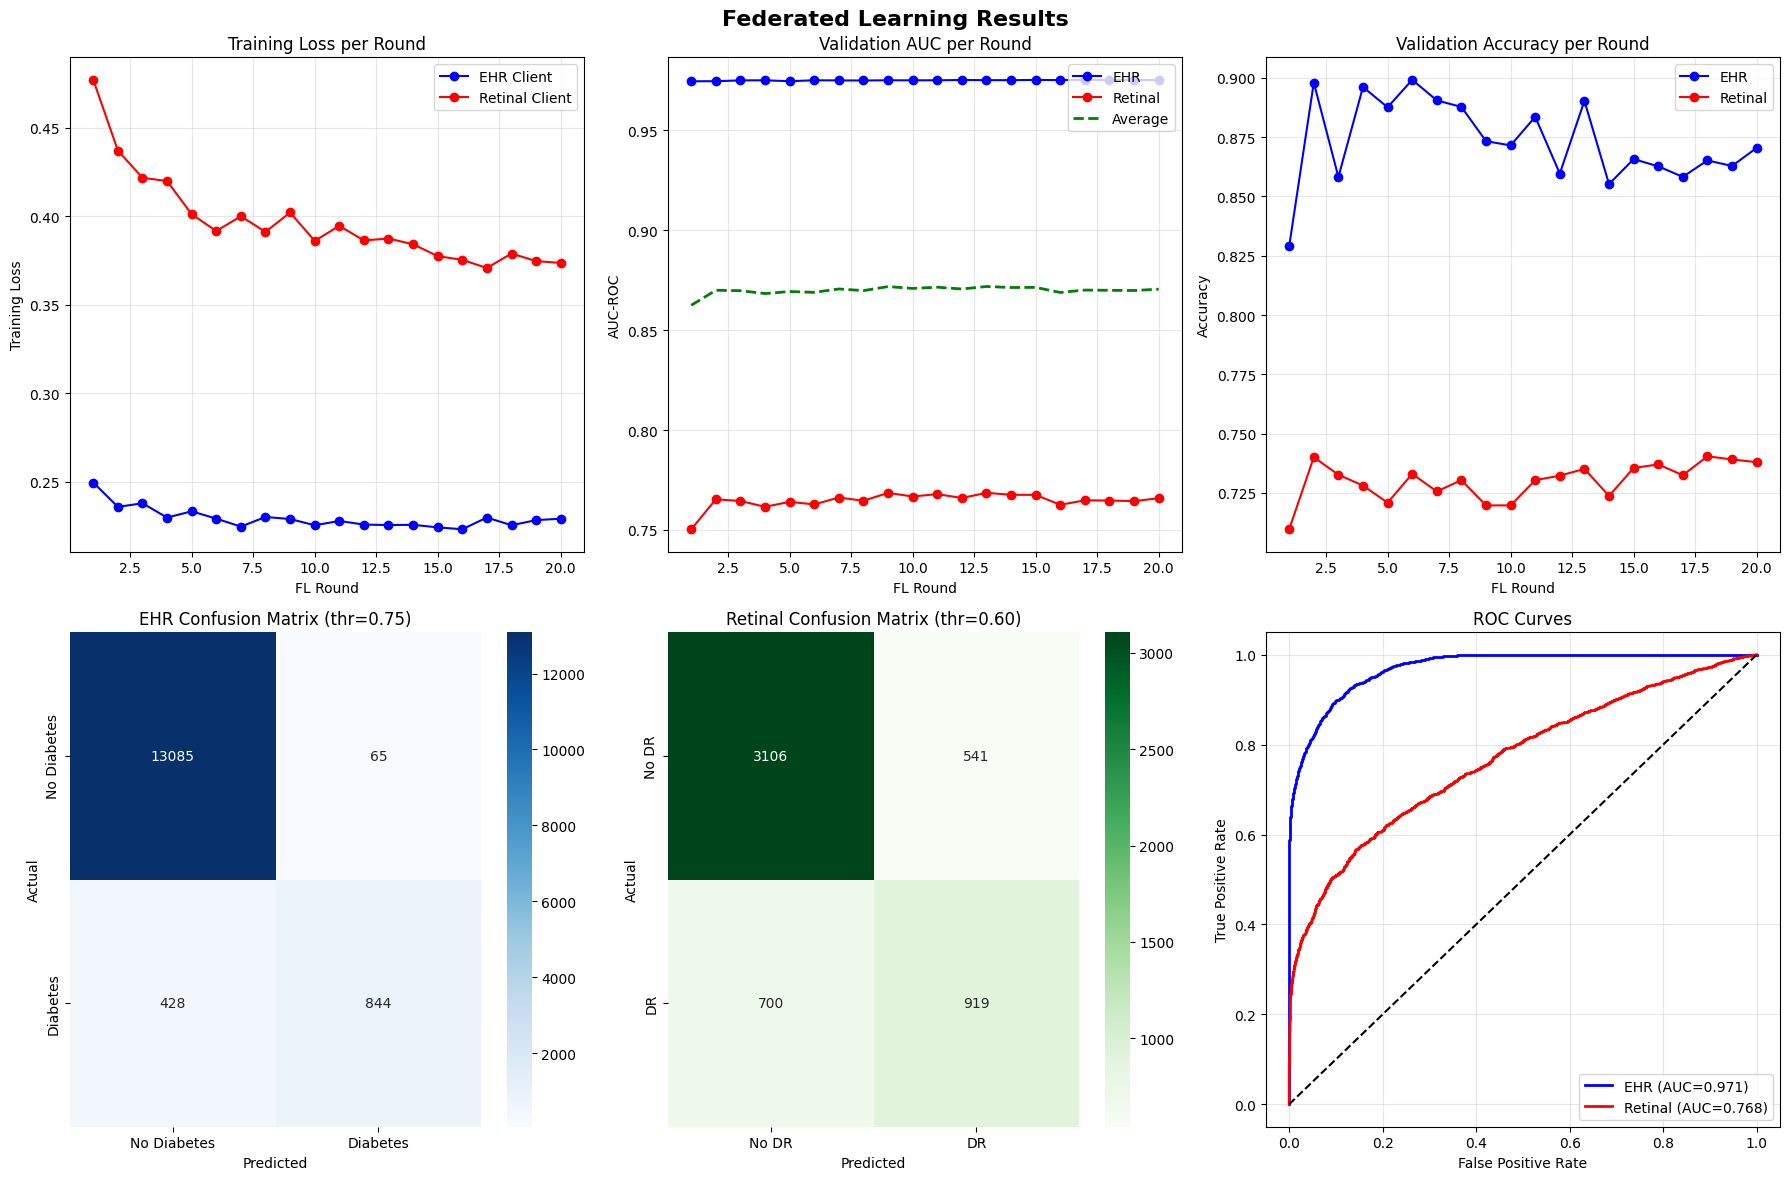


✓ Saved: /content/drive/MyDrive/MULTIMODAL/models/fl_results.png


In [ ]:
# ============================================================
# CELL 13: VISUALIZATIONS
# ============================================================

print("\n" + "=" * 70)
print("STEP 9: VISUALIZATIONS")
print("=" * 70)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Federated Learning Results', fontsize=16, fontweight='bold')

# ─────────────────────────────────────────────────────────
# Plot 1: Training Loss per Round
# ─────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(fl_history['round'], fl_history['ehr_train_loss'], 'b-o', label='EHR Client')
ax.plot(fl_history['round'], fl_history['ret_train_loss'], 'r-o', label='Retinal Client')
ax.set_xlabel('FL Round')
ax.set_ylabel('Training Loss')
ax.set_title('Training Loss per Round')
ax.legend()
ax.grid(alpha=0.3)

# ─────────────────────────────────────────────────────────
# Plot 2: Validation AUC per Round
# ─────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(fl_history['round'], fl_history['ehr_val_auc'], 'b-o', label='EHR')
ax.plot(fl_history['round'], fl_history['ret_val_auc'], 'r-o', label='Retinal')
avg_auc = [(e + r) / 2 for e, r in zip(fl_history['ehr_val_auc'], fl_history['ret_val_auc'])]
ax.plot(fl_history['round'], avg_auc, 'g--', label='Average', linewidth=2)
ax.set_xlabel('FL Round')
ax.set_ylabel('AUC-ROC')
ax.set_title('Validation AUC per Round')
ax.legend()
ax.grid(alpha=0.3)

# ─────────────────────────────────────────────────────────
# Plot 3: Validation Accuracy per Round
# ─────────────────────────────────────────────────────────
ax = axes[0, 2]
ax.plot(fl_history['round'], fl_history['ehr_val_acc'], 'b-o', label='EHR')
ax.plot(fl_history['round'], fl_history['ret_val_acc'], 'r-o', label='Retinal')
ax.set_xlabel('FL Round')
ax.set_ylabel('Accuracy')
ax.set_title('Validation Accuracy per Round')
ax.legend()
ax.grid(alpha=0.3)

# ─────────────────────────────────────────────────────────
# Plot 4: EHR Confusion Matrix
# ─────────────────────────────────────────────────────────
ax = axes[1, 0]
cm_ehr = confusion_matrix(ehr_test_metrics['labels'], ehr_preds_optimal)
sns.heatmap(cm_ehr, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
ax.set_title(f'EHR Confusion Matrix (thr={ehr_best_thr:.2f})')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# ─────────────────────────────────────────────────────────
# Plot 5: Retinal Confusion Matrix
# ─────────────────────────────────────────────────────────
ax = axes[1, 1]
cm_ret = confusion_matrix(ret_test_metrics['labels'], ret_preds_optimal)
sns.heatmap(cm_ret, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['No DR', 'DR'],
            yticklabels=['No DR', 'DR'])
ax.set_title(f'Retinal Confusion Matrix (thr={ret_best_thr:.2f})')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')

# ─────────────────────────────────────────────────────────
# Plot 6: ROC Curves
# ─────────────────────────────────────────────────────────
ax = axes[1, 2]

# EHR ROC
fpr_ehr, tpr_ehr, _ = roc_curve(ehr_test_metrics['labels'], ehr_test_metrics['probs'])
ax.plot(fpr_ehr, tpr_ehr, 'b-', linewidth=2, label=f'EHR (AUC={ehr_test_metrics["auc"]:.3f})')

# Retinal ROC
fpr_ret, tpr_ret, _ = roc_curve(ret_test_metrics['labels'], ret_test_metrics['probs'])
ax.plot(fpr_ret, tpr_ret, 'r-', linewidth=2, label=f'Retinal (AUC={ret_test_metrics["auc"]:.3f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(config.SAVE_DIR, 'fl_results.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: {config.SAVE_DIR}/fl_results.png")

## **14. Save Global Model**

In [ ]:
# ============================================================
# CELL 14: SAVE GLOBAL MODEL
# ============================================================

print("\n" + "=" * 70)
print("STEP 10: SAVING GLOBAL MODEL")
print("=" * 70)

# Save the global model
save_path = os.path.join(config.SAVE_DIR, config.GLOBAL_MODEL_NAME)

checkpoint = {
    'model_state_dict': best_global_state,
    'ehr_dim': ehr_dim,
    'img_dim': img_dim,
    'fl_config': {
        'num_rounds': config.NUM_ROUNDS,
        'local_epochs_ehr': config.LOCAL_EPOCHS_EHR,
        'local_epochs_retinal': config.LOCAL_EPOCHS_RETINAL,
        'lr_ehr': config.LR_EHR,
        'lr_retinal': config.LR_RETINAL,
        'freeze_encoders': config.FREEZE_ENCODERS
    },
    'fl_history': fl_history,
    'test_results': {
        'ehr': {
            'auc': ehr_test_metrics['auc'],
            'accuracy': ehr_test_metrics['accuracy'],
            'f1': ehr_test_metrics['f1'],
            'optimal_threshold': ehr_best_thr
        },
        'retinal': {
            'auc': ret_test_metrics['auc'],
            'accuracy': ret_test_metrics['accuracy'],
            'f1': ret_test_metrics['f1'],
            'optimal_threshold': ret_best_thr
        }
    },
    'ehr_model_config': ehr_checkpoint.get('config', {}),
    'retinal_model_config': ret_checkpoint.get('config', {})
}

torch.save(checkpoint, save_path)
print(f"✓ Global model saved to: {save_path}")


STEP 10: SAVING GLOBAL MODEL
✓ Global model saved to: /content/drive/MyDrive/MULTIMODAL/models/global_multimodal_fl.pth


## **15. Final Summary**

In [ ]:
# ============================================================
# CELL 15: FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FEDERATED LEARNING SUMMARY")
print("=" * 70)

print(f"""
Configuration:
────────────────────────────────────────
  FL Rounds:           {config.NUM_ROUNDS}
  Local Epochs (EHR):  {config.LOCAL_EPOCHS_EHR}
  Local Epochs (Ret):  {config.LOCAL_EPOCHS_RETINAL}
  Freeze Encoders:     {config.FREEZE_ENCODERS}
  Aggregation:         FedAvg (weighted by dataset size)

Data:
────────────────────────────────────────
  EHR Train:      {len(ehr_train_df):,} samples
  EHR Test:       {len(ehr_test_df):,} samples
  Retinal Train:  {len(ret_train_df):,} samples
  Retinal Test:   {len(ret_test_df):,} samples

Model Architecture:
────────────────────────────────────────
  EHR Encoder:      MLP → {ehr_dim} features
  Retinal Encoder:  EfficientNet-B2 → {img_dim} features
  Combined:         {ehr_dim + img_dim} features
  Classifier:       {ehr_dim + img_dim} → 256 → 64 → 1

Test Results (Global FL Model):
────────────────────────────────────────
  EHR Modality:
    AUC:       {ehr_test_metrics['auc']:.4f}
    Accuracy:  {accuracy_score(ehr_test_metrics['labels'], ehr_preds_optimal):.4f} (thr={ehr_best_thr:.2f})
    F1-Score:  {ehr_best_f1:.4f}

  Retinal Modality:
    AUC:       {ret_test_metrics['auc']:.4f}
    Accuracy:  {accuracy_score(ret_test_metrics['labels'], ret_preds_optimal):.4f} (thr={ret_best_thr:.2f})
    F1-Score:  {ret_best_f1:.4f}

  Average AUC: {(ehr_test_metrics['auc'] + ret_test_metrics['auc']) / 2:.4f}

Files Saved:
────────────────────────────────────────
  Global Model: {config.SAVE_DIR}/{config.GLOBAL_MODEL_NAME}
  Plot:         {config.SAVE_DIR}/fl_results.png

────────────────────────────────────────
✓ FEDERATED LEARNING COMPLETE
────────────────────────────────────────
""")


FEDERATED LEARNING SUMMARY

Configuration:
────────────────────────────────────────
  FL Rounds:           20
  Local Epochs (EHR):  1
  Local Epochs (Ret):  1
  Freeze Encoders:     True
  Aggregation:         FedAvg (weighted by dataset size)

Data:
────────────────────────────────────────
  EHR Train:      11,876 samples
  EHR Test:       14,422 samples
  Retinal Train:  15,128 samples
  Retinal Test:   5,266 samples

Model Architecture:
────────────────────────────────────────
  EHR Encoder:      MLP → 32 features
  Retinal Encoder:  EfficientNet-B2 → 1408 features
  Combined:         1440 features
  Classifier:       1440 → 256 → 64 → 1

Test Results (Global FL Model):
────────────────────────────────────────
  EHR Modality:
    AUC:       0.9714
    Accuracy:  0.9658 (thr=0.75)
    F1-Score:  0.7740

  Retinal Modality:
    AUC:       0.7675
    Accuracy:  0.7643 (thr=0.60)
    F1-Score:  0.5969

  Average AUC: 0.8695

Files Saved:
────────────────────────────────────────
  Glob

**16. Helper Code for Loading Global Model**

In [ ]:
# ============================================================
# CELL 16: HELPER CODE FOR LOADING GLOBAL MODEL
# ============================================================

print("\n" + "=" * 70)
print("HELPER CODE FOR LOADING GLOBAL MODEL")
print("=" * 70)

helper_code = '''
# ============================================================
# Copy this code to load the global FL model in other notebooks
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

# Define model classes (same as training)
class EHRClassifier(nn.Module):
    def __init__(self, n_features, hidden_dims=[128, 64, 32], dropout_rate=0.3):
        super().__init__()
        layers = []
        in_dim = n_features
        for i, out_dim in enumerate(hidden_dims):
            layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate if i < len(hidden_dims) - 1 else dropout_rate * 0.5)
            ])
            in_dim = out_dim
        self.feature_extractor = nn.Sequential(*layers)
        self.feature_dim = hidden_dims[-1]

class BinaryDRClassifier(nn.Module):
    def __init__(self, model_name='efficientnet_b2', dropout=0.3):
        super().__init__()
        self.backbone = models.efficientnet_b2(weights=None)
        n = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.feature_dim = n

class GlobalMultimodalModel(nn.Module):
    def __init__(self, ehr_encoder, ret_encoder, ehr_dim, img_dim):
        super().__init__()
        self.ehr_encoder = ehr_encoder
        self.ret_encoder = ret_encoder
        self.ehr_dim = ehr_dim
        self.img_dim = img_dim
        self.classifier = nn.Sequential(
            nn.Linear(ehr_dim + img_dim, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(64, 1)
        )

    def forward_ehr(self, x_ehr):
        ehr_feats = self.ehr_encoder(x_ehr)
        img_zero = x_ehr.new_zeros(x_ehr.size(0), self.img_dim)
        fused = torch.cat([ehr_feats, img_zero], dim=1)
        return self.classifier(fused)

    def forward_retinal(self, x_img):
        img_feats = self.ret_encoder(x_img)
        ehr_zero = x_img.new_zeros(x_img.size(0), self.ehr_dim)
        fused = torch.cat([ehr_zero, img_feats], dim=1)
        return self.classifier(fused)

# Load global model
def load_global_model(checkpoint_path, ehr_model_path, ret_model_path, device='cpu'):
    # Load checkpoints
    global_ckpt = torch.load(checkpoint_path, map_location=device)
    ehr_ckpt = torch.load(ehr_model_path, map_location=device)
    ret_ckpt = torch.load(ret_model_path, map_location=device)

    # Create EHR encoder
    ehr_model = EHRClassifier(
        n_features=ehr_ckpt['n_features'],
        hidden_dims=ehr_ckpt['hidden_dims']
    )
    ehr_model.load_state_dict(ehr_ckpt['model_state_dict'])

    # Create Retinal encoder
    ret_model = BinaryDRClassifier()
    ret_model.load_state_dict(ret_ckpt['model_state_dict'])

    # Create global model
    model = GlobalMultimodalModel(
        ehr_encoder=ehr_model.feature_extractor,
        ret_encoder=ret_model.backbone,
        ehr_dim=global_ckpt['ehr_dim'],
        img_dim=global_ckpt['img_dim']
    )
    model.load_state_dict(global_ckpt['model_state_dict'])
    model.to(device)
    model.eval()

    return model, global_ckpt

# Usage:
# model, ckpt = load_global_model(
#     'global_multimodal_fl.pth',
#     'mlp_ehr_binary_diabetes.pth',
#     'efficientnet_b2_binary_dr_twostage.pth'
# )
#
# # For EHR inference:
# logits = model.forward_ehr(ehr_data)
# probs = torch.sigmoid(logits)
#
# # For Retinal inference:
# logits = model.forward_retinal(retinal_images)
# probs = torch.sigmoid(logits)
'''

print(helper_code)

print("\n" + "=" * 70)
print("✓ NOTEBOOK COMPLETE")
print("=" * 70)


HELPER CODE FOR LOADING GLOBAL MODEL

# ============================================================
# Copy this code to load the global FL model in other notebooks
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

# Define model classes (same as training)
class EHRClassifier(nn.Module):
    def __init__(self, n_features, hidden_dims=[128, 64, 32], dropout_rate=0.3):
        super().__init__()
        layers = []
        in_dim = n_features
        for i, out_dim in enumerate(hidden_dims):
            layers.extend([
                nn.Linear(in_dim, out_dim),
                nn.BatchNorm1d(out_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate if i < len(hidden_dims) - 1 else dropout_rate * 0.5)
            ])
            in_dim = out_dim
        self.feature_extractor = nn.Sequential(*layers)
        self.feature_dim = hidden_dims[-1]

class BinaryDRClassifier(nn.Module):
    def _